# Crypto Premium Index: Funding Rate Arbitrage Data

**Docker image**: `ml4t`

## Purpose
Explore the Binance perpetual-futures premium index — the per-period deviation between
perpetual and spot prices that determines the funding rate paid every 8 hours. The
notebook profiles 19 USDT-margined perpetuals from 2020-01 to 2025-12 and turns the
raw premium series into estimated funding APY for the funding-arbitrage case study.

## Learning Objectives
- Load the 8-hour premium-index panel and read its schema.
- Characterize the distribution and time-series behavior of BTC premium.
- Compare premium volatility across majors and altcoins.
- Translate premium into Binance's clamped funding rate and an annualized return.

## Book reference
Chapter 2, §2.2 (asset-class market data — crypto datasets). The funding-arbitrage
case study built on this dataset lives in `case_studies/crypto_perps_funding/`.

## Prerequisites
- Crypto perpetual + premium parquet files materialized under `ML4T_DATA_PATH`.
- Loader `data.load_crypto_premium`.

---

In [1]:
"""Crypto Premium Index — Funding rate arbitrage data exploration."""

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_crypto_premium

In [2]:
# Production defaults — Papermill injects overrides for CI

---

## Section 1: Understanding the Premium Index

### What is the Premium Index?

The **Premium Index** measures the deviation between perpetual futures prices and spot prices:

$$\text{Premium Index} = \frac{\text{Perpetual Price} - \text{Spot Price}}{\text{Spot Price}}$$

### Key Properties:

1. **Positive Premium**: Perpetual > Spot → Longs pay Shorts (bullish sentiment)
2. **Negative Premium**: Perpetual < Spot → Shorts pay Longs (bearish sentiment)
3. **Funding Rate**: Derived from premium index, paid every 8 hours on Binance

### Arbitrage Opportunity

When premium is significantly positive:
- **Long Spot** + **Short Perpetual** = Collect funding payments
- Market-neutral position captures the funding rate

When premium is significantly negative:
- **Short Spot** + **Long Perpetual** = Collect funding payments

In [3]:
# Load the combined premium index data
premium_df = load_crypto_premium(frequency="8h")

print(f"Total rows: {len(premium_df):,}")
print(f"Columns: {premium_df.columns}")
print("\nSchema:")
for col, dtype in premium_df.schema.items():
    print(f"  {col}: {dtype}")

Total rows: 107,839
Columns: ['timestamp', 'symbol', 'premium_index_open', 'premium_index_high', 'premium_index_low', 'premium_index_close']

Schema:
  timestamp: Datetime(time_unit='ms', time_zone='UTC')
  symbol: String
  premium_index_open: Float64
  premium_index_high: Float64
  premium_index_low: Float64
  premium_index_close: Float64


In [4]:
# Overview by asset
symbol_stats = (
    premium_df.group_by("symbol")
    .agg(
        [
            pl.col("timestamp").min().alias("start"),
            pl.col("timestamp").max().alias("end"),
            pl.len().alias("rows"),
            pl.col("premium_index_close").mean().alias("avg_premium"),
            pl.col("premium_index_close").std().alias("std_premium"),
        ]
    )
    .sort("rows", descending=True)
)

symbol_stats

symbol,start,end,rows,avg_premium,std_premium
str,"datetime[ms, UTC]","datetime[ms, UTC]",u32,f64,f64
"""BTCUSDT""",2020-01-01 00:00:00 UTC,2025-12-31 16:00:00 UTC,6555,-0.000113,0.000557
"""ETHUSDT""",2020-01-01 00:00:00 UTC,2025-12-31 16:00:00 UTC,6555,-0.000055,0.000628
"""XRPUSDT""",2020-01-06 08:00:00 UTC,2025-12-31 16:00:00 UTC,6542,-0.000049,0.001109
"""LINKUSDT""",2020-01-17 08:00:00 UTC,2025-12-31 16:00:00 UTC,6506,-0.000045,0.00068
"""ADAUSDT""",2020-01-31 08:00:00 UTC,2025-12-31 16:00:00 UTC,6464,-0.000058,0.000659
…,…,…,…,…,…
"""AAVEUSDT""",2020-10-16 00:00:00 UTC,2025-12-31 16:00:00 UTC,5688,-0.000069,0.000701
"""MKRUSDT""",2020-08-13 00:00:00 UTC,2025-10-22 08:00:00 UTC,5672,-0.000003,0.000744
"""INJUSDT""",2022-08-17 00:00:00 UTC,2025-12-31 16:00:00 UTC,3693,-0.00025,0.000697


In [5]:
# Sample data - BTC premium index
btc_premium = premium_df.filter(pl.col("symbol") == "BTCUSDT").sort("timestamp")

print(f"BTC Premium Index: {len(btc_premium):,} 8h observations")
print(f"Date range: {btc_premium['timestamp'].min()} to {btc_premium['timestamp'].max()}")

btc_premium.head(10)

BTC Premium Index: 6,555 8h observations
Date range: 2020-01-01 00:00:00+00:00 to 2025-12-31 16:00:00+00:00


timestamp,symbol,premium_index_open,premium_index_high,premium_index_low,premium_index_close
"datetime[ms, UTC]",str,f64,f64,f64,f64
2020-01-01 00:00:00 UTC,"""BTCUSDT""",-0.000777,-0.0001,-0.001206,-0.000482
2020-01-01 08:00:00 UTC,"""BTCUSDT""",-0.000578,-0.000005,-0.001179,-0.000281
2020-01-01 16:00:00 UTC,"""BTCUSDT""",-0.000282,0.000094,-0.000892,-0.00029
2020-01-02 00:00:00 UTC,"""BTCUSDT""",-0.000309,0.000612,-0.001409,-0.000453
2020-01-02 08:00:00 UTC,"""BTCUSDT""",-0.000594,0.000218,-0.000621,-0.000206
2020-01-02 16:00:00 UTC,"""BTCUSDT""",-0.000206,-0.000206,-0.000206,-0.000206
2020-01-03 00:00:00 UTC,"""BTCUSDT""",-0.000502,-0.000025,-0.000783,-0.000331
2020-01-03 08:00:00 UTC,"""BTCUSDT""",-0.000478,0.001002,-0.001511,-0.000212
2020-01-03 16:00:00 UTC,"""BTCUSDT""",-0.000297,0.000357,-0.001188,-0.000555


---

## Section 2: Premium Index Distribution

Understanding the distribution of premium values is crucial for:
1. Setting entry/exit thresholds for arbitrage
2. Risk management (tail events)
3. Comparing opportunities across assets

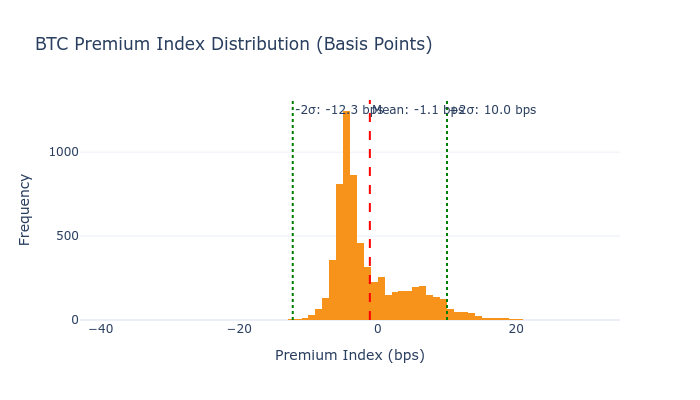

In [6]:
# BTC Premium distribution
btc_close = btc_premium["premium_index_close"].to_numpy()

# Convert to basis points for readability
btc_close_bps = btc_close * 10000

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=btc_close_bps,
        nbinsx=100,
        name="BTC Premium",
        marker_color="#F7931A",
    )
)

# Add vertical lines for mean and +-2 std
mean_val = np.mean(btc_close_bps)
std_val = np.std(btc_close_bps)

fig.add_vline(
    x=mean_val, line_dash="dash", line_color="red", annotation_text=f"Mean: {mean_val:.1f} bps"
)
fig.add_vline(
    x=mean_val + 2 * std_val,
    line_dash="dot",
    line_color="green",
    annotation_text=f"+2σ: {mean_val + 2 * std_val:.1f} bps",
)
fig.add_vline(
    x=mean_val - 2 * std_val,
    line_dash="dot",
    line_color="green",
    annotation_text=f"-2σ: {mean_val - 2 * std_val:.1f} bps",
)

fig.update_layout(
    title="BTC Premium Index Distribution (Basis Points)",
    xaxis_title="Premium Index (bps)",
    yaxis_title="Frequency",
    height=400,
    template="plotly_white",
)
fig.show()

In [7]:
print("BTC Premium Statistics:")
print(f"  Mean: {mean_val:.2f} bps")
print(f"  Std:  {std_val:.2f} bps")
print(f"  Min:  {np.min(btc_close_bps):.2f} bps")
print(f"  Max:  {np.max(btc_close_bps):.2f} bps")
print(f"  Skew: {((btc_close_bps - mean_val) ** 3).mean() / std_val**3:.2f}")

BTC Premium Statistics:
  Mean: -1.13 bps
  Std:  5.57 bps
  Min:  -42.38 bps
  Max:  34.18 bps
  Skew: 1.24


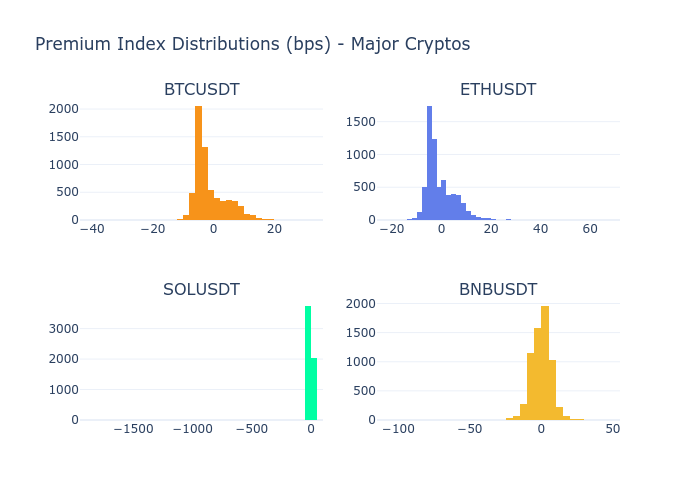

In [8]:
# Compare premium distributions across major assets
major_symbols = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT"]

fig = make_subplots(rows=2, cols=2, subplot_titles=major_symbols)

colors = ["#F7931A", "#627EEA", "#00FFA3", "#F3BA2F"]

for idx, (symbol, color) in enumerate(zip(major_symbols, colors, strict=False)):
    row = idx // 2 + 1
    col = idx % 2 + 1

    data = premium_df.filter(pl.col("symbol") == symbol)["premium_index_close"].to_numpy() * 10000

    fig.add_trace(
        go.Histogram(x=data, nbinsx=50, marker_color=color, name=symbol), row=row, col=col
    )

fig.update_layout(
    title="Premium Index Distributions (bps) - Major Cryptos",
    height=500,
    showlegend=False,
    template="plotly_white",
)
fig.show()

---

## Section 3: Time Series Analysis

Premium index varies over time based on market sentiment. Let's analyze:
1. Long-term trends
2. Regime changes (bull vs bear markets)
3. Correlation with price movements

In [9]:
# BTC premium time series.
# Data is on an 8h cadence (3 obs per day), so 30 days = 90 windows.
PERIODS_PER_DAY = 3  # Binance funding interval is 8h
ROLLING_WINDOW_DAYS = 30

btc_bps = btc_premium.with_columns(
    (pl.col("premium_index_close") * 10000).alias("premium_bps"),
).with_columns(
    pl.col("premium_index_close")
    .rolling_mean(window_size=ROLLING_WINDOW_DAYS * PERIODS_PER_DAY)
    .alias("rolling_30d"),
)

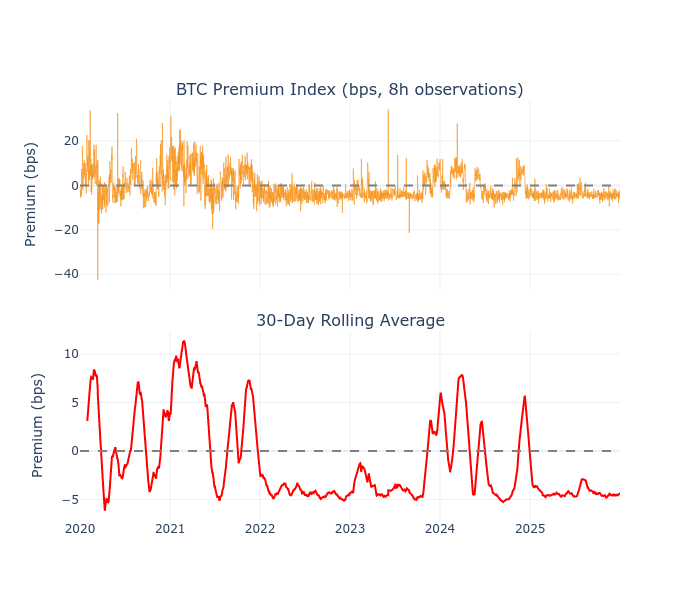

In [10]:
# Plot raw 8h premium and 30-day rolling mean
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=[
        "BTC Premium Index (bps, 8h observations)",
        f"{ROLLING_WINDOW_DAYS}-Day Rolling Average",
    ],
)

fig.add_trace(
    go.Scatter(
        x=btc_bps["timestamp"].to_list(),
        y=btc_bps["premium_bps"].to_list(),
        mode="lines",
        name="8h Premium",
        line=dict(color="#F7931A", width=1),
        opacity=0.6,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=btc_bps["timestamp"].to_list(),
        y=(btc_bps["rolling_30d"] * 10000).to_list(),
        mode="lines",
        name="30-Day Rolling Avg",
        line=dict(color="red", width=2),
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)
fig.update_layout(height=600, template="plotly_white", showlegend=False)
fig.update_yaxes(title_text="Premium (bps)", row=1, col=1)
fig.update_yaxes(title_text="Premium (bps)", row=2, col=1)
fig.show()

In [11]:
# Report the observed BTC range so the reader can size the y-axis.
btc_bps_series = btc_bps["premium_bps"]
print(f"BTC premium range: {btc_bps_series.min():.1f} to {btc_bps_series.max():.1f} bps")

BTC premium range: -42.4 to 34.2 bps


In [12]:
# Identify premium regimes
btc_regimes = btc_premium.with_columns(
    [
        # Define regimes based on premium level
        pl.when(pl.col("premium_index_close") > 0.001)
        .then(pl.lit("High Premium (Bullish)"))
        .when(pl.col("premium_index_close") < -0.001)
        .then(pl.lit("Low Premium (Bearish)"))
        .otherwise(pl.lit("Neutral"))
        .alias("regime"),
        # Year for grouping
        pl.col("timestamp").dt.year().alias("year"),
    ]
)

# Regime distribution by year (counts of 8h periods, ~1095 per full year)
regime_dist = (
    btc_regimes.group_by(["year", "regime"])
    .agg(pl.len().alias("periods_8h"))
    .sort(["year", "regime"])
)

regime_dist.pivot(on="regime", index="year", values="periods_8h").fill_null(0)

year,High Premium (Bullish),Low Premium (Bearish),Neutral
i32,u32,u32,u32
2020,89,19,990
2021,172,12,896
2022,0,3,1089
2023,9,1,1082
2024,23,0,1075
2025,0,0,1095


---

## Section 4: Cross-Asset Premium Comparison

Different cryptocurrencies have different premium dynamics:
- **BTC/ETH**: Lower volatility, tighter premiums
- **Altcoins**: Higher volatility, wider premium swings

This affects arbitrage opportunity selection.

In [13]:
# Calculate premium statistics for all assets
premium_stats = (
    premium_df.group_by("symbol")
    .agg(
        [
            pl.col("premium_index_close").mean().alias("mean_premium"),
            pl.col("premium_index_close").std().alias("std_premium"),
            pl.col("premium_index_close").min().alias("min_premium"),
            pl.col("premium_index_close").max().alias("max_premium"),
            # Percentage of time premium > 10 bps (profitable arbitrage threshold)
            (pl.col("premium_index_close").abs() > 0.001).mean().alias("pct_above_10bps"),
        ]
    )
    .sort("std_premium", descending=True)
)

# Convert to basis points for display
premium_stats_bps = premium_stats.with_columns(
    [
        (pl.col("mean_premium") * 10000).round(2).alias("mean_bps"),
        (pl.col("std_premium") * 10000).round(2).alias("std_bps"),
        (pl.col("min_premium") * 10000).round(2).alias("min_bps"),
        (pl.col("max_premium") * 10000).round(2).alias("max_bps"),
        (pl.col("pct_above_10bps") * 100).round(1).alias("pct_above_10bps"),
    ]
).select(["symbol", "mean_bps", "std_bps", "min_bps", "max_bps", "pct_above_10bps"])

premium_stats_bps

symbol,mean_bps,std_bps,min_bps,max_bps,pct_above_10bps
str,f64,f64,f64,f64,f64
"""SOLUSDT""",-2.6,36.71,-1915.47,93.51,9.4
"""XRPUSDT""",-0.49,11.09,-698.42,65.23,9.0
"""UNIUSDT""",-0.65,10.11,-582.57,54.52,10.2
"""COMPUSDT""",-1.96,10.09,-318.57,61.06,13.6
"""ATOMUSDT""",-1.11,8.34,-205.16,66.51,13.8
…,…,…,…,…,…
"""DOTUSDT""",-1.51,6.76,-73.04,57.2,11.3
"""ADAUSDT""",-0.58,6.59,-84.29,47.62,9.6
"""ETHUSDT""",-0.55,6.28,-24.35,71.06,6.7


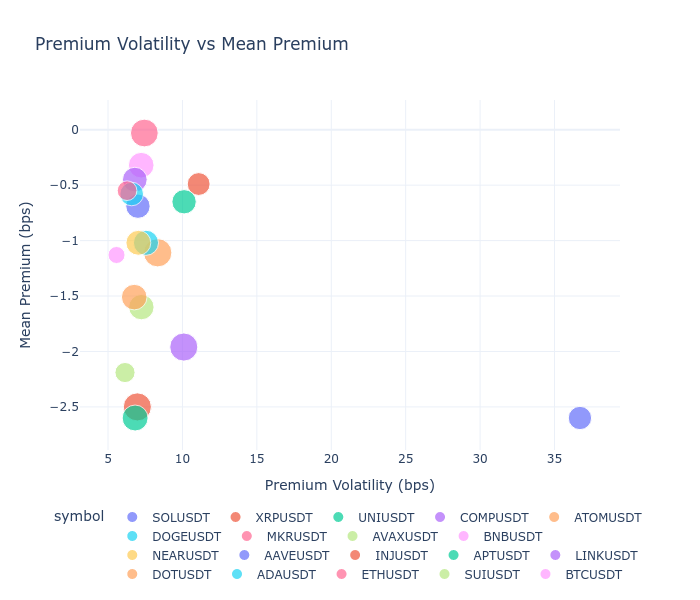


Interpretation:
- Top-right quadrant: High volatility, positive bias (bullish altcoins)
- Larger bubbles: More arbitrage opportunities (premium often > 10bps)


In [14]:
# Scatter: Premium volatility vs mean premium
fig = px.scatter(
    premium_stats_bps.to_pandas(),
    x="std_bps",
    y="mean_bps",
    size="pct_above_10bps",
    color="symbol",
    hover_name="symbol",
    title="Premium Volatility vs Mean Premium",
    labels={
        "std_bps": "Premium Volatility (bps)",
        "mean_bps": "Mean Premium (bps)",
        "pct_above_10bps": "% Time > 10bps",
    },
)

fig.update_layout(
    height=600,
    template="plotly_white",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5,
    ),
    margin=dict(b=120),
)
fig.show()

print("\nInterpretation:")
print("- Top-right quadrant: High volatility, positive bias (bullish altcoins)")
print("- Larger bubbles: More arbitrage opportunities (premium often > 10bps)")

In [15]:
# Monthly premium heatmap
# Note: Some months have extreme values (e.g., SOL during FTX collapse at -72 bps)
# We clip the color scale at ±20 bps for better visualization of typical patterns

monthly_premium = (
    premium_df.with_columns([pl.col("timestamp").dt.strftime("%Y-%m").alias("month")])
    .group_by(["symbol", "month"])
    .agg(pl.col("premium_index_close").mean().alias("avg_premium"))
)

# Pivot for heatmap
heatmap_data = monthly_premium.pivot(on="month", index="symbol", values="avg_premium").sort(
    "symbol"
)

# Get month columns in order
month_cols = sorted([c for c in heatmap_data.columns if c != "symbol"])
assets = heatmap_data["symbol"].to_list()

# Extract values for heatmap
z_values = heatmap_data.select(month_cols).to_numpy() * 10000  # Convert to bps

# Clip color scale at ±20 bps for better visualization
COLOR_CLIP_BPS = 20

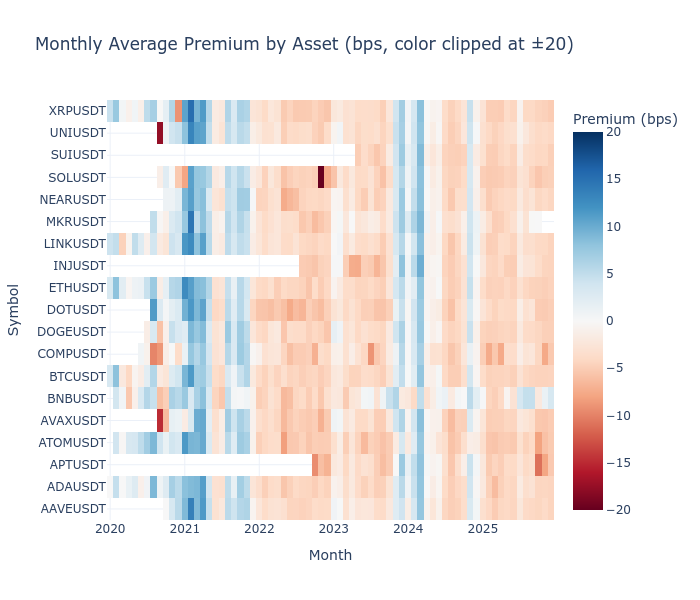

symbol,month,avg_bps
str,str,f64
"""SOLUSDT""","""2022-11""",-61.7


In [16]:
fig = go.Figure(
    data=go.Heatmap(
        z=z_values,
        x=month_cols,
        y=assets,
        colorscale="RdBu",
        zmid=0,
        zmin=-COLOR_CLIP_BPS,
        zmax=COLOR_CLIP_BPS,
        colorbar=dict(title="Premium (bps)"),
    )
)

fig.update_layout(
    title=f"Monthly Average Premium by Asset (bps, color clipped at ±{COLOR_CLIP_BPS})",
    xaxis_title="Month",
    yaxis_title="Symbol",
    height=600,
    template="plotly_white",
)
fig.show()

# Report extremes that exceed color scale (shown as saturated colors)
extremes = (
    monthly_premium.filter(pl.col("avg_premium").abs() * 10000 > COLOR_CLIP_BPS)
    .with_columns((pl.col("avg_premium") * 10000).round(1).alias("avg_bps"))
    .select(["symbol", "month", "avg_bps"])
    .sort("avg_bps")
)
extremes

---

## Section 5: Funding Rate Estimation

Binance calculates funding rates from premium index every 8 hours:

$$\text{Funding Rate} = \text{clamp}(\text{Premium Index}, -0.05\%, 0.05\%) + \text{Interest Rate}$$

Where Interest Rate ≈ 0.01% (0.03%/day).

**Annualized Return** from funding collection:
$$\text{APY} = \text{Funding Rate} \times 3 \times 365$$

In [17]:
# Calculate estimated funding rates using native Polars expressions
# Formula: funding_rate = clamp(premium, -0.05%, 0.05%) + interest_rate
# Interest rate ≈ 0.01% per 8h (0.0001)
INTEREST_RATE = 0.0001

btc_funding = btc_premium.with_columns(
    # Clamp premium to [-0.05%, 0.05%] and add interest rate
    (pl.col("premium_index_close").clip(-0.0005, 0.0005) + INTEREST_RATE).alias("est_funding_rate"),
).with_columns(
    # Annualized return: 3 funding periods/day * 365 days * 100 for percentage
    (pl.col("est_funding_rate") * 3 * 365 * 100).alias("annualized_pct"),
)

avg_funding_rate = float(btc_funding["est_funding_rate"].mean())
ann_min = float(btc_funding["annualized_pct"].min())
ann_max = float(btc_funding["annualized_pct"].max())
ann_mean = float(btc_funding["annualized_pct"].mean())
print("BTC Estimated Funding Rate Analysis:")
print(f"  Average funding rate (per 8h): {avg_funding_rate * 100:.4f}%")
print(f"  Annualized return (avg): {ann_mean:.1f}%")
print(f"  Annualized return (max): {ann_max:.1f}%")
print(f"  Annualized return (min): {ann_min:.1f}%")

BTC Estimated Funding Rate Analysis:
  Average funding rate (per 8h): -0.0052%
  Annualized return (avg): -5.7%
  Annualized return (max): 65.7%
  Annualized return (min): -43.8%


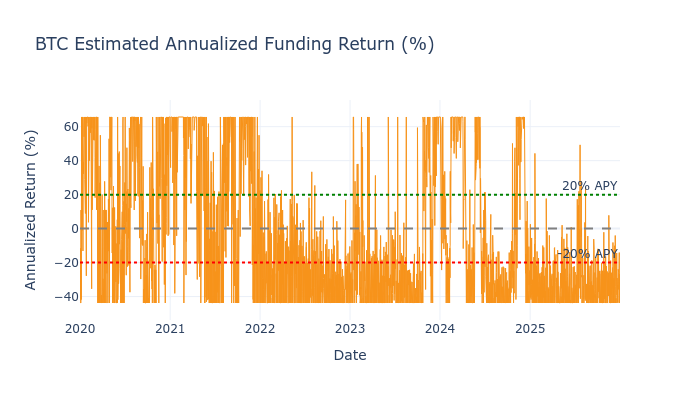

Annualized funding return range: -43.8% to 65.7%


In [18]:
# Visualize annualized funding returns over time
# Note: Funding rate is clamped to ±0.05% per period, so annualized range is bounded
# to approximately ±55% (3 periods/day × 365 days × 0.05%)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=btc_funding["timestamp"].to_list(),
        y=btc_funding["annualized_pct"].to_list(),
        mode="lines",
        name="Annualized Funding Return",
        line=dict(color="#F7931A", width=1),
    )
)

# Add horizontal lines for reference
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.add_hline(y=20, line_dash="dot", line_color="green", annotation_text="20% APY")
fig.add_hline(y=-20, line_dash="dot", line_color="red", annotation_text="-20% APY")

y_padding = 10
fig.update_layout(
    title="BTC Estimated Annualized Funding Return (%)",
    xaxis_title="Date",
    yaxis_title="Annualized Return (%)",
    yaxis=dict(range=[ann_min - y_padding, ann_max + y_padding]),
    height=400,
    template="plotly_white",
)
fig.show()

print(f"Annualized funding return range: {ann_min:.1f}% to {ann_max:.1f}%")

In [19]:
# 8h periods where the estimated funding APY exceeds ±20%.
# Note: the funding-rate clamp pins per-period funding at ±0.0005 + 0.0001 interest,
# so the APY ceiling is 3 × 365 × 0.0006 × 100 ≈ 65.7% (and floor ≈ −43.8%);
# the top rows therefore all sit at the clamp.
high_conviction = btc_funding.filter(pl.col("annualized_pct").abs() > 20)

print(
    f"High-conviction periods (|APY| > 20%): {len(high_conviction):,} of {len(btc_funding):,} 8h periods"
)
print(f"Share of total: {len(high_conviction) / len(btc_funding) * 100:.1f}%")

(
    high_conviction.sort("annualized_pct", descending=True)
    .head(10)
    .select(["timestamp", "premium_index_close", "est_funding_rate", "annualized_pct"])
)

High-conviction periods (|APY| > 20%): 5,436 of 6,555 8h periods
Share of total: 82.9%


timestamp,premium_index_close,est_funding_rate,annualized_pct
"datetime[ms, UTC]",f64,f64,f64
2020-01-07 08:00:00 UTC,0.0007422,0.0006,65.7
2020-01-08 16:00:00 UTC,0.000609,0.0006,65.7
2020-01-10 16:00:00 UTC,0.001772,0.0006,65.7
2020-01-11 00:00:00 UTC,0.001042,0.0006,65.7
2020-01-12 00:00:00 UTC,0.000578,0.0006,65.7
2020-01-14 16:00:00 UTC,0.0009549,0.0006,65.7
2020-01-15 00:00:00 UTC,0.000539,0.0006,65.7
2020-01-16 00:00:00 UTC,0.000998,0.0006,65.7
2020-01-16 08:00:00 UTC,0.000638,0.0006,65.7


---

## Section 6: Using the CryptoDataManager

The ml4t-data library provides a `CryptoDataManager` for convenient access to the premium index data.

In [20]:
# Using the CryptoDataManager (requires ml4t-data library)
# This demonstrates the programmatic API for loading crypto data
from ml4t.data.crypto import CryptoDataManager  # noqa: F401

# CryptoDataManager provides a clean API for loading crypto data
# For this notebook, we use direct parquet loading as shown above
print("CryptoDataManager API available from ml4t-data library.")
print("For this analysis, we use direct parquet loading for simplicity.")

CryptoDataManager API available from ml4t-data library.
For this analysis, we use direct parquet loading for simplicity.


---

## Key Takeaways

Profile of the Binance premium-index panel underpinning the funding-arbitrage
case study.

### Quantitative Findings
- **Panel scale**: 107,839 8h observations across 19 USDT-margined perpetuals,
  2020-01-01 → 2025-12-31. Coverage ranges from BTC/ETH (6,555 obs) down to
  SUIUSDT (2,920 obs from May 2023).
- **Slight short bias**: All 19 symbols have a *negative* mean premium
  (between −0.03 and −2.6 bps; MKR is essentially flat), so on average
  perpetuals trade *below* spot — the raw funding flow is from shorts to
  longs before adding the interest-rate baseline.
- **Volatility spectrum**: BTC has the tightest premium (std 5.6 bps).
  ETH/ADA/DOT cluster at 6–7 bps (~1.2× BTC). The wide-tail altcoins are
  SOL (std 36.7 bps, min −1,915 bps during the FTX collapse), XRP/UNI/COMP
  (10–11 bps), reflecting episodic dislocation rather than steady-state
  volatility.
- **Arbitrage frequency**: |premium| > 10 bps in 5–14 % of 8h periods
  depending on the symbol (BTC 5.0 %, COMP/ATOM 13–14 %).
- **Funding APY**: Binance's clamped funding rate (±0.05 % + 0.01 % interest)
  bounds the BTC annualized return at +65.7 % / −43.8 %. Realised mean is
  −5.7 % over 2020-25; the clamp is hit in 82.9 % of 8h periods (driven by
  the interest-rate baseline pushing |APY| above 20 % whenever premium is
  small).

### Implications for the Funding-Arbitrage Case Study
- **Direction matters**: The negative mean premium means a *delta-neutral
  short-spot / long-perpetual* leg captures the structural funding flow on
  average for these symbols; the mirror trade only profits during transient
  bullish dislocations.
- **Asset selection**: Wide-tail altcoins (SOL, XRP, COMP) offer the largest
  per-event funding but expose the strategy to extreme premium tails.
  BTC/ETH provide a tighter, more reliable funding stream.
- **Regime awareness**: The 30-day rolling premium swings between bull (2021)
  and bear (2022) regimes; static thresholds will mis-fire — see the
  `case_studies/crypto_perps_funding/` pipeline for the regime-aware signal
  used downstream.

**Next**: `12_fx_pairs_eda` profiles the third 24/7-adjacent dataset —
G10 FX pairs at 4h cadence — completing the global market-data tour.